# **Implementación de Modelos Predictivo**

## **1.Importación de Librerias** 

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris


In [79]:
df = pd.read_csv('avocado_clean.csv')

Límite inferior: 0.26
Límite superior: 2.50
Cantidad de outliers: 209


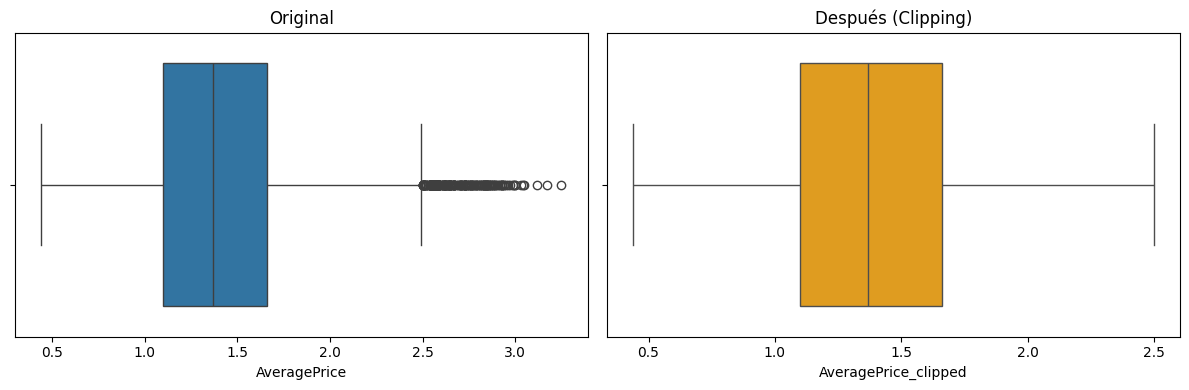

In [80]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Q1 = df['AveragePrice'].quantile(0.25)
Q3 = df['AveragePrice'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")

outliers = df[(df['AveragePrice'] < lower_bound) |
              (df['AveragePrice'] > upper_bound)]

print(f"Cantidad de outliers: {len(outliers)}")

df['AveragePrice_clipped'] = np.clip(
    df['AveragePrice'], lower_bound, upper_bound
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['AveragePrice'], ax=axes[0])
axes[0].set_title('Original')

sns.boxplot(x=df['AveragePrice_clipped'], ax=axes[1], color='orange')
axes[1].set_title('Después (Clipping)')

plt.tight_layout()
plt.show()

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

X = df.drop(columns=['AveragePrice', 'AveragePrice_clipped'])
y = df['AveragePrice_clipped']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred)}")
print(f"R²: {r2_score(y_test, y_pred)}")

Error Cuadrático Medio: 0.07152821608468792
R²: 0.5418618093019216


## **2. Regresión Lineal**

In [82]:
X = df.drop(columns=['AveragePrice', 'AveragePrice_clipped'])
y = df['AveragePrice_clipped']
# Dividir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [83]:
modelo = LinearRegression()
modelo.fit(X_train, y_train)
y_pred_lr = modelo.predict(X_test)

In [84]:
print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_lr)}")
print(f"R²: {r2_score(y_test, y_pred_lr)}")

Error Cuadrático Medio: 0.07152821608468792
R²: 0.5418618093019216


## **3. Ramdom Forest**


In [85]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, max_depth=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_rf)}")
print(f"R²: {r2_score(y_test, y_pred_rf)}")


Error Cuadrático Medio: 0.025656361837671227
R²: 0.8356710143827824


## **4. Redes Neuronales**

In [86]:
from sklearn.neural_network import MLPRegressor

mlp = MLPRegressor(hidden_layer_sizes=(500,250), max_iter=100, early_stopping=False, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
print(f"Error Cuadrático Medio: {mean_squared_error(y_test, y_pred_mlp)}")
print(f"R²: {r2_score(y_test, y_pred_mlp)}")

Error Cuadrático Medio: 0.04383963253253917
R²: 0.7192071740535741


C:\Users\LENOVO-PC\AppData\Roaming\Python\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


## **#. Tabla Comparativa**

In [87]:
tabla_resultados = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Random Forest', 'Red Neuronal'],
    'MSE': [
        mean_squared_error(y_test, y_pred_lr),
        mean_squared_error(y_test, y_pred_rf),
        mean_squared_error(y_test, y_pred_mlp)
    ],
    'R²': [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_mlp)
    ]
})

tabla_resultados

,Modelo,MSE,R²
0,Regresión Lineal,0.071528,0.541862
1,Random Forest,0.025656,0.835671
2,Red Neuronal,0.043840,0.719207


                  MSE    MAE     R²
Regresión\nLineal   0  0.204  0.542
Random\nForest      0  0.115  0.836
Red\nNeuronal       0  0.153  0.719


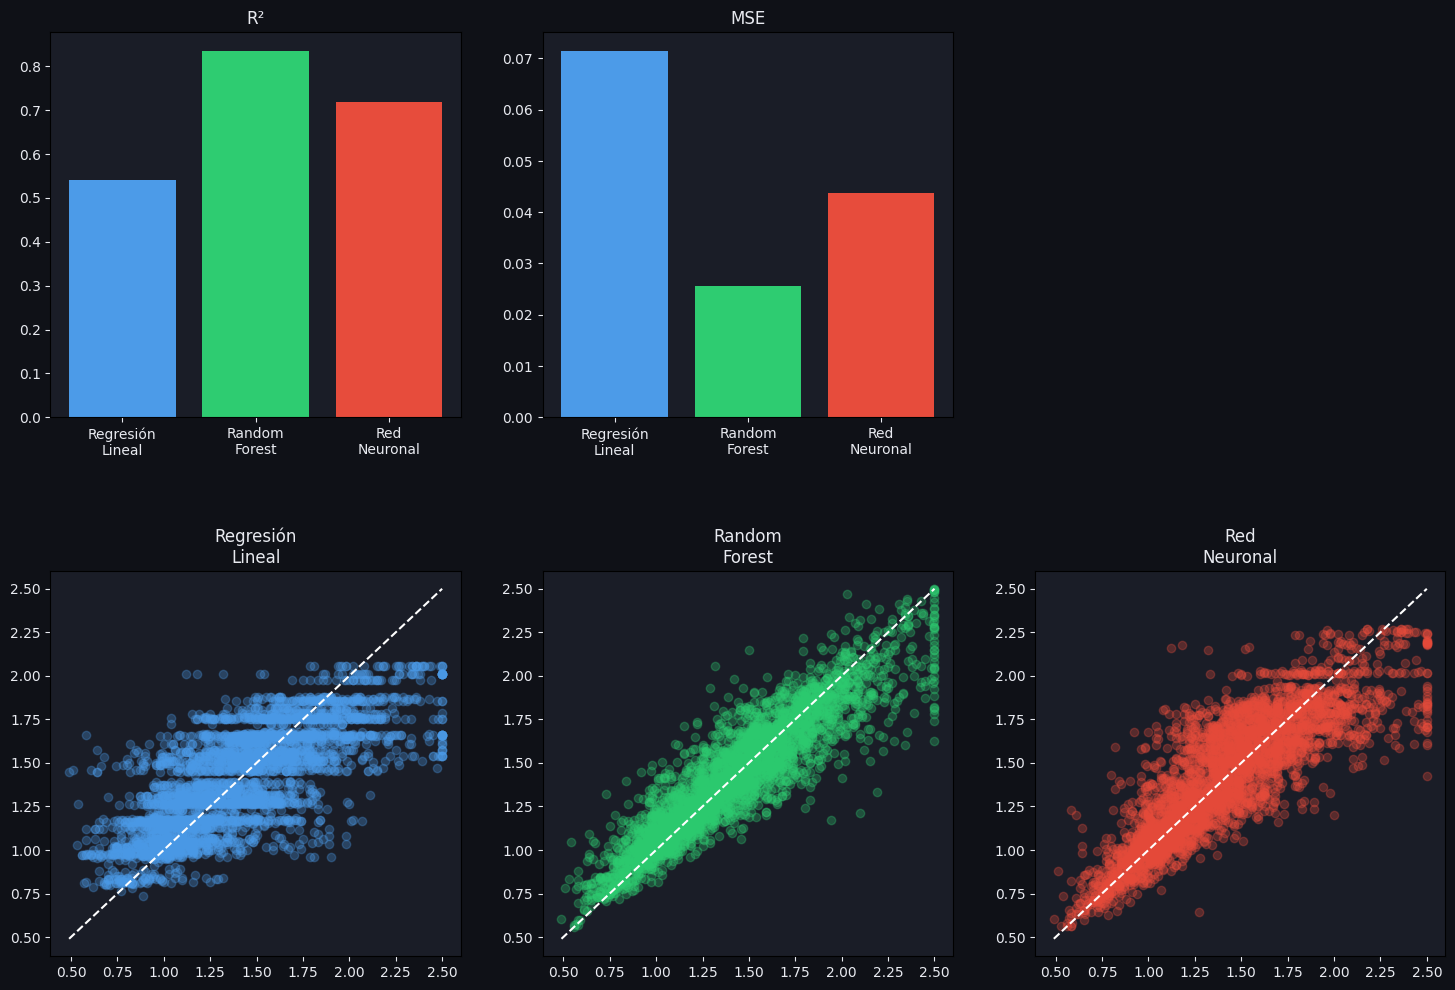

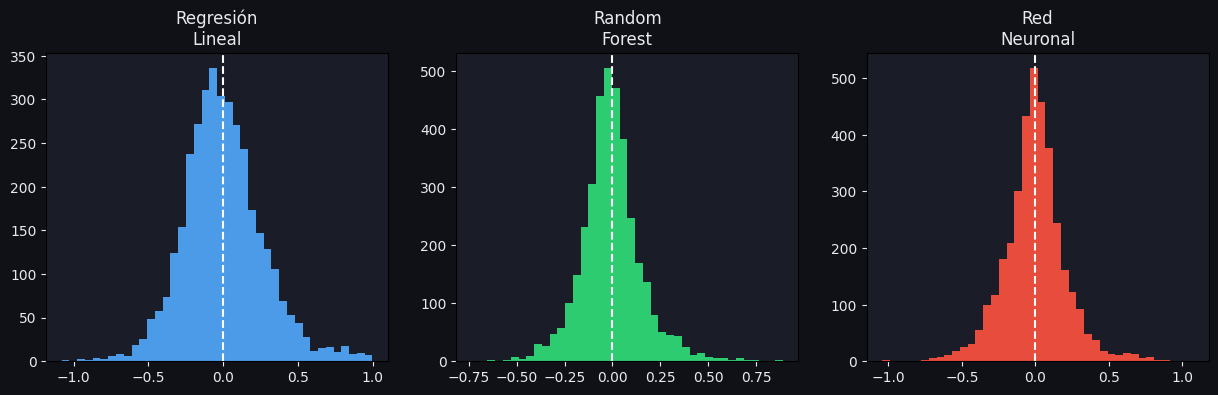

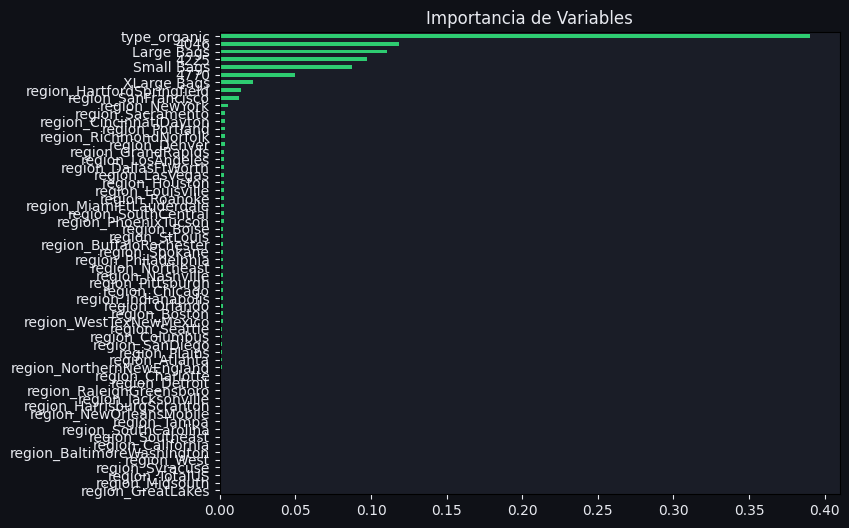

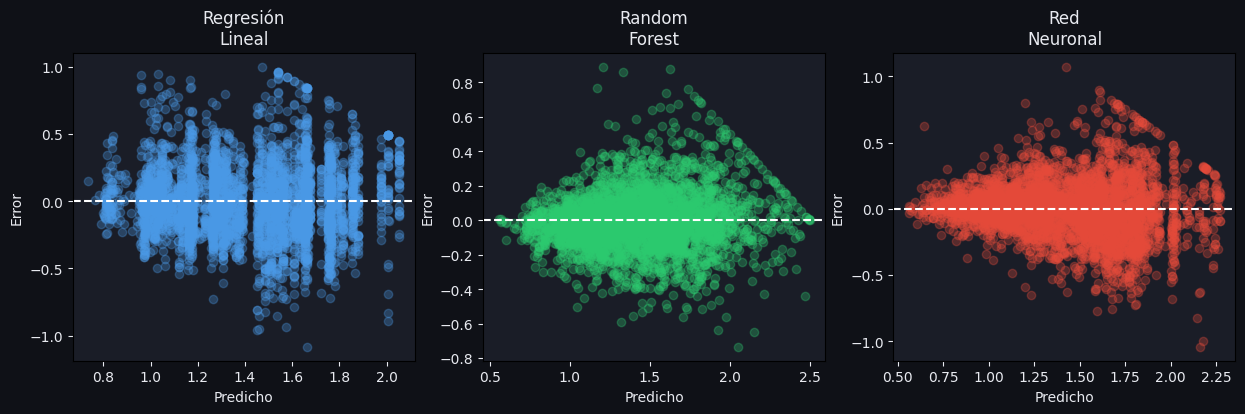

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

COLORS = {
    "LR":  "#4C9BE8",
    "RF":  "#2ECC71",
    "MLP": "#E74C3C",
    "bg":  "#0F1117",
    "card":"#1A1D27",
    "text":"#E8EAF0",
    "grid":"#2A2D3A",
}

plt.rcParams.update({
    "figure.facecolor": COLORS["bg"],
    "axes.facecolor": COLORS["card"],
    "text.color": COLORS["text"],
    "axes.labelcolor": COLORS["text"],
    "xtick.color": COLORS["text"],
    "ytick.color": COLORS["text"],
})

preds = {
    "Regresión\nLineal": y_pred_lr,
    "Random\nForest": y_pred_rf,
    "Red\nNeuronal": y_pred_mlp
}

colors_list = [COLORS["LR"], COLORS["RF"], COLORS["MLP"]]


metrics = {}
for name, yp in preds.items():
    metrics[name] = {
        "MSE":  mean_squared_error(y_test, yp),
        "MAE":  mean_absolute_error(y_test, yp),
        "R²":   r2_score(y_test, yp),
    }

df_metrics = pd.DataFrame(metrics).T

df_show = df_metrics.copy()
df_show["MSE"]  = df_show["MSE"].map(lambda x: f"{x:,.0f}")
df_show["MAE"]  = df_show["MAE"].map(lambda x: f"{x:.3f}")
df_show["R²"]   = df_show["R²"].map(lambda x: f"{x:.3f}")

print(df_show)

# FIGURA 1 — Dashboard
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4)

# R²
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(df_metrics.index, df_metrics["R²"], color=colors_list)
ax1.set_title("R²")

# MSE
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(df_metrics.index, df_metrics["MSE"], color=colors_list) 
ax2.set_title("MSE")


# Scatter
for i, (name, yp) in enumerate(preds.items()):
    ax = fig.add_subplot(gs[1, i])
    ax.scatter(y_test, yp, alpha=0.3, color=colors_list[i])
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()], 'w--')
    ax.set_title(name)

plt.show()

# FIGURA 2 — Residuos
fig2, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, yp), col in zip(axes, preds.items(), colors_list):
    residuos = y_test.values - yp
    ax.hist(residuos, bins=40, color=col)
    ax.axvline(0, color='white', linestyle='--')
    ax.set_title(name)

plt.show()

# FIGURA 3 — Importancia RF
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values().plot(kind='barh', figsize=(8,6), color=COLORS["RF"])
plt.title("Importancia de Variables")
plt.show()


# FIGURA 4 — Error vs Predicción
fig4, axes4 = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, yp), col in zip(axes4, preds.items(), colors_list):
    error = y_test.values - yp
    ax.scatter(yp, error, color=col, alpha=0.3)
    ax.axhline(0, linestyle='--', color='white')
    ax.set_title(name)
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Error")

plt.show()